In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import  color , segmentation


In [9]:
image =cv2.imread('cham.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray=cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

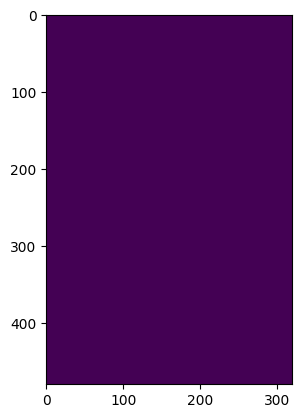

In [ ]:
_,thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY)
thresh
plt.imshow(thresh, cmap='gray')


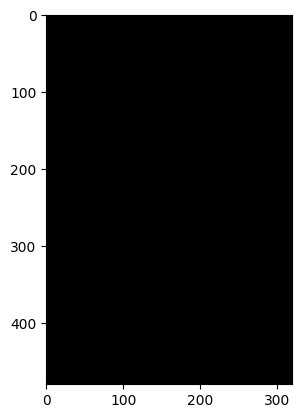

In [15]:
edges=cv2.Canny(thresh, 100, 200)
plt.imshow(edges, cmap='gray')

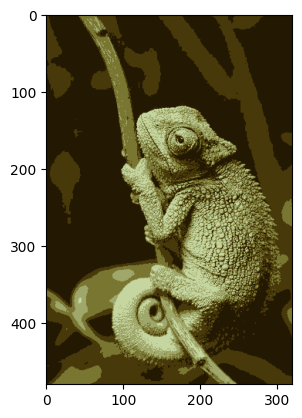

In [17]:
#clustering
Z=image.reshape((-1,3)).astype(np.float32)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K=5
_, label, center = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
center = np.uint8(center)
kmeans_image = center[label.flatten()].reshape(image.shape)
plt.imshow(kmeans_image)